<a href="https://colab.research.google.com/github/akosinyll1404/Machine-Learning-Projects/blob/main/De_los_Reyes_Polynomial_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Objective(s):

This activity aims to perform regression analysis using polynomial regression

#### Intended Learning Outcomes (ILOs):
* Demonstrate how to build a regression model to predict the outcome using polynomial regression.
* Evaluate the performance of the regression model using polynomial regression

#### Resources:
* Jupyter Notebook
* internet_traffic_hist.csv




#### Procedure:

#### Using numpy polyfit to perform polynomial regression
Import the libraries and the data

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
from sklearn.metrics import r2_score
from scipy.optimize import curve_fit

Load the dataset

In [ ]:
internet = '/content/internet_traffic_hist-2.csv'

df_hist = pd.read_csv(internet)
df_hist.head(11)

,traffic,year
0,100.000000,2005
1,126.933755,2006
2,160.303757,2007
3,203.390603,2008
4,241.292566,2009
5,308.791823,2010
6,379.980659,2011
7,495.840568,2012
8,616.207252,2013
9,752.103483,2014


Build the first order polynomial using numpy polyfit

The slope of line is 79.52710966244513.
The y intercept is -159457.12265833947.
The best fit simple linear regression line is 79.52710966244513x + -159457.12265833947.


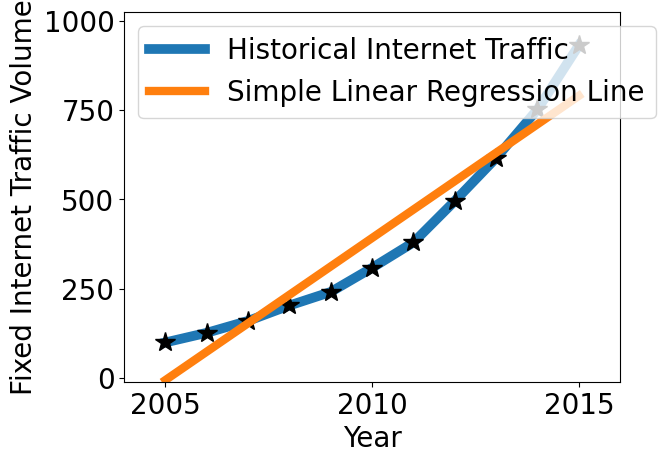

In [ ]:
order = 1

# XY Plot of year and traffic
x = df_hist.year
y = df_hist.traffic

m, b = np.polyfit(x,y,order)

plt.plot(x, y, label = 'Historical Internet Traffic', linewidth = 7)
plt.plot(x, y,'*k', markersize = 15, label ='')
plt.plot(x, m*x + b, '-', label = 'Simple Linear Regression Line', linewidth = 6)

print ('The slope of line is {}.'.format(m))
print ('The y intercept is {}.'.format(b))
print ('The best fit simple linear regression line is {}x + {}.'.format(m,b))


#Increase sligthly the axis sizes to make the plot more clear
plt.axis([x.iloc[0]-1, x.iloc[-1]+1, y.iloc[0]*-0.1, y.iloc[-1]*1.1])

# Add axis labels
plt.xlabel('Year')
plt.ylabel('Fixed Internet Traffic Volume')
plt.legend(loc = 'upper left')


# Increase default font size
plt.rcParams.update({'font.size': 26})
plt.show()

Build the model using Higher Order Polynomial (1 to 4)

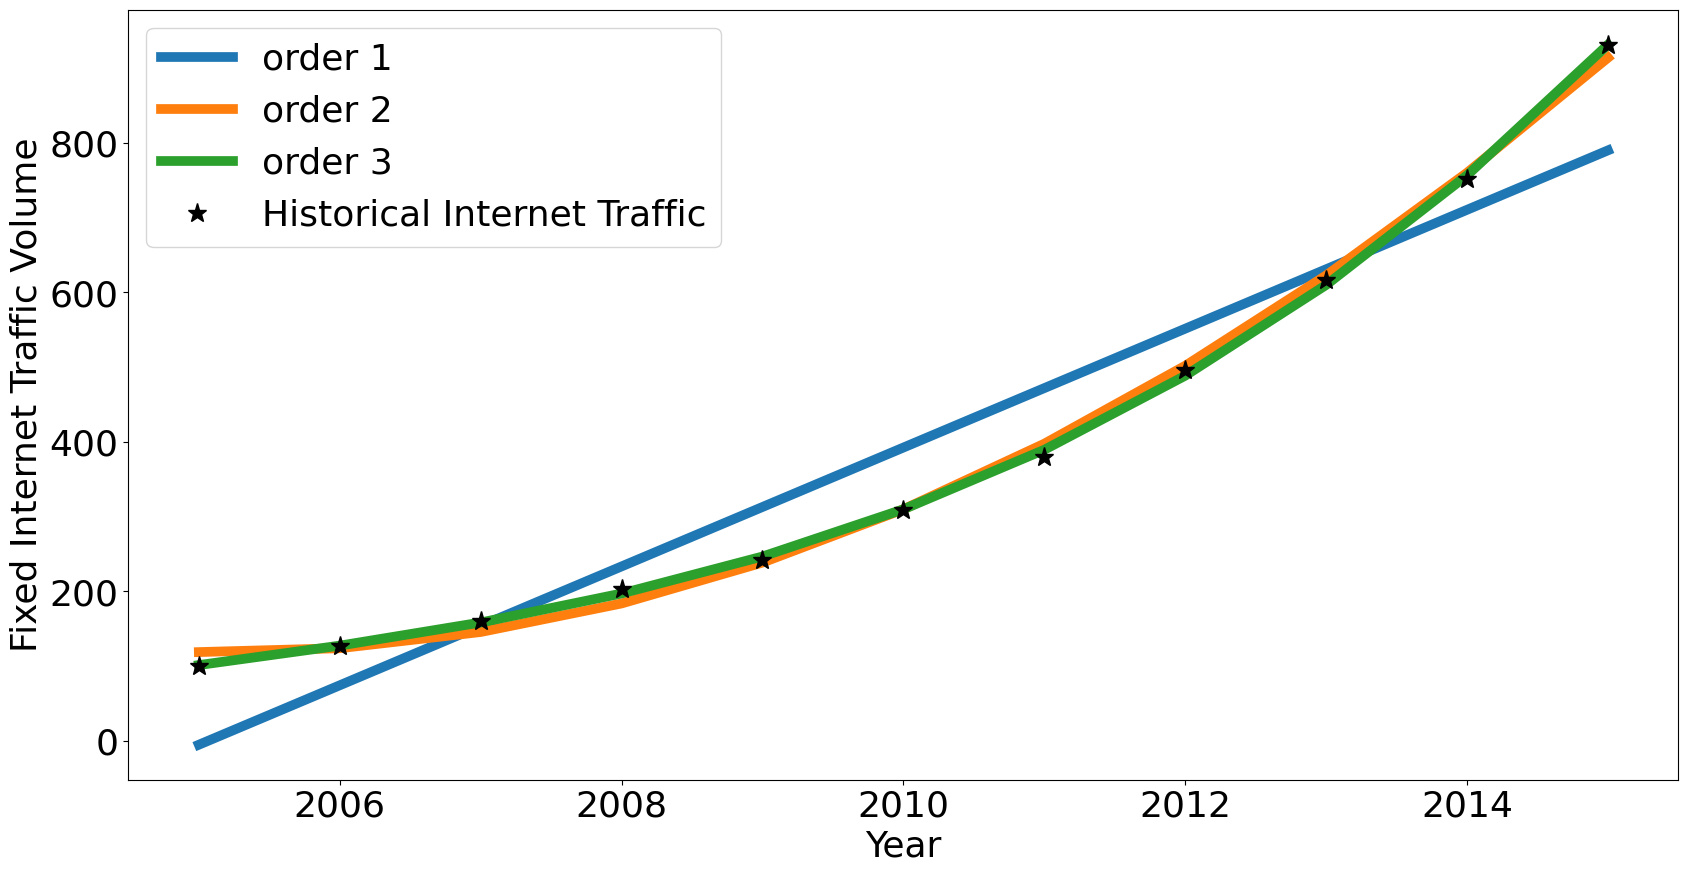

In [ ]:
models = []       # to store polynomial model parameters (list of poly1d objects)
errors_hist = []  # to store the absolute errors for each point (2005-2015) and for each model (list of numpy arrays )
mse_hist = []     # to store the MSE for each model (list of numpy floats)

#Try polynomial models with increasing order
for order in range(1,4):
    # Fit polynomial model
    p = (np.poly1d(np.polyfit(x, y, order)))
    models.append(p)

plt.figure(figsize = (20,10))

# Visualize polynomial models fit
for model in models[0:3]:
    plt.plot(x, model(x), label = 'order ' + str(len(model)), linewidth = 7)

plt.plot(x, y, '*k', markersize = 14, label = 'Historical Internet Traffic', linewidth = 7)
plt.legend(loc = 'upper left')

# Add axis labels
plt.xlabel('Year')
plt.ylabel('Fixed Internet Traffic Volume')

plt.show()

Calculate the error for each order

In [ ]:
# Calculate and store the errors
models = []       # to store polynomial model parameters (list of poly1d objects)
errors_hist = []  # to store the absolute errors for each point (2005-2015) and for each model (list of numpy arrays )
mse_hist = []     # to store the MSE for each model (list of numpy floats)

#Try polynomial models with increasing order
for order in range(1,4):
    # Fit polynomial model
    p = (np.poly1d(np.polyfit(x, y, order)))
    models.append(p)

    e = np.abs(y-p(x))        # absolute error
    mse = np.sum(e**2)/len(df_hist) # mse

    errors_hist.append(e)   #Store the absolute errors
    mse_hist.append(mse) # Store the mse

In [ ]:
mse_hist

[5483.842045937108, 156.25749108223093, 25.17218620372407]

In [ ]:
errors_hist

[0     105.267785
 1      52.674431
 2       6.517323
 3      29.922941
 4      71.548088
 5      83.575940
 6      91.914214
 7      55.581414
 8      14.741840
 9      41.627281
 10    141.197617
 Name: traffic, dtype: float64,
 0     18.700083
 1      3.087283
 2     14.781847
 3     19.664207
 4      2.832633
 5      0.930694
 6     17.533493
 7      5.994267
 8      6.477316
 9      7.959866
 10    17.229749
 Name: traffic, dtype: float64,
 0     1.307430
 1     0.391253
 2     2.027227
 3     6.329832
 4     5.283944
 5     0.930698
 6     9.416922
 7     7.340101
 8     6.277297
 9     4.481339
 10    0.162915
 Name: traffic, dtype: float64]

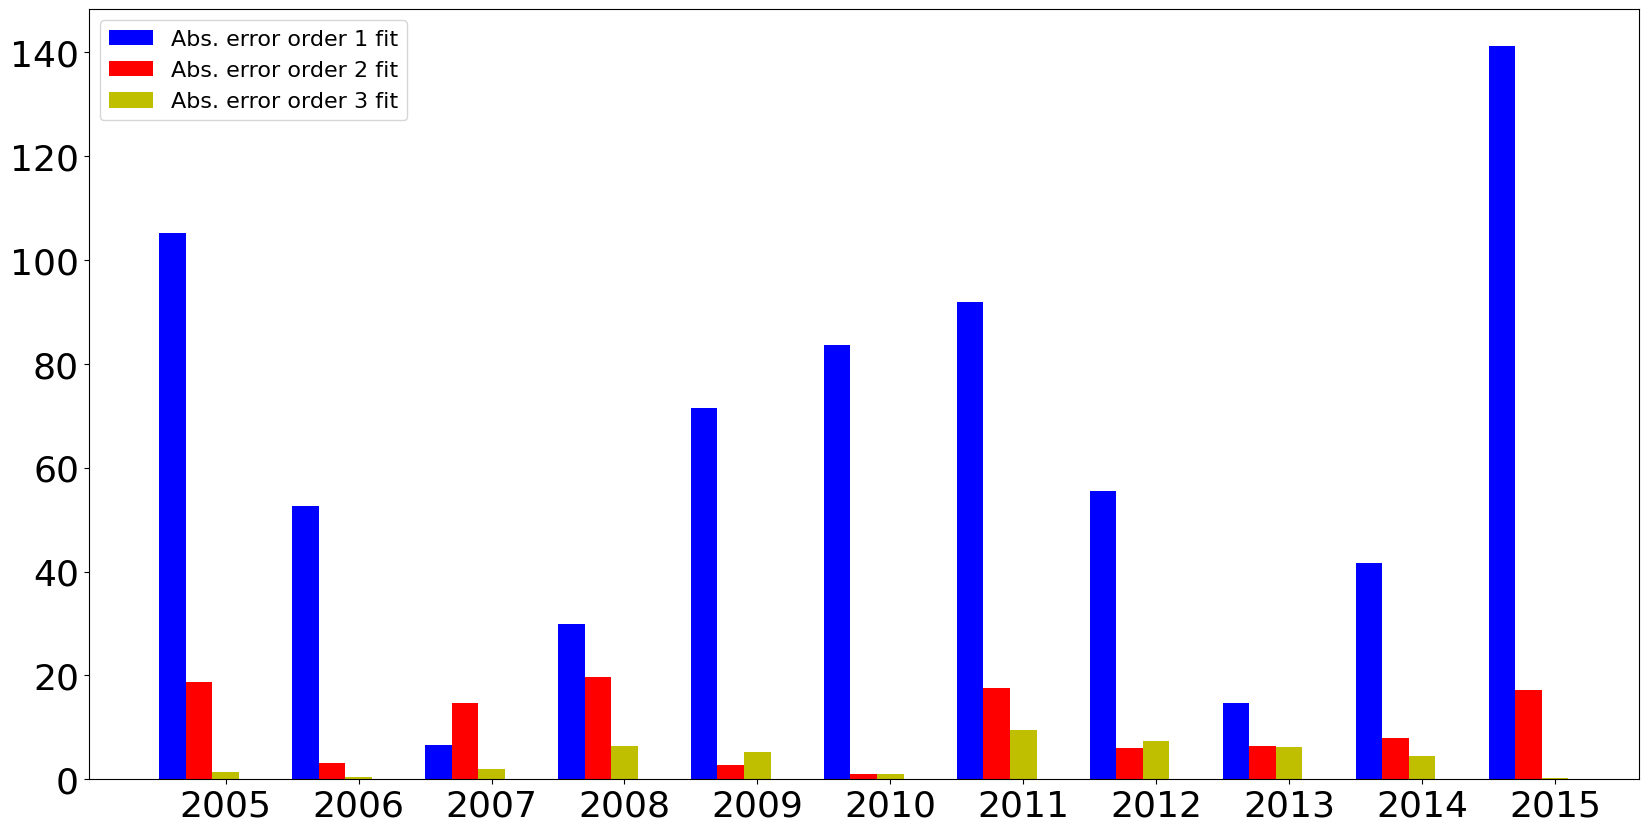

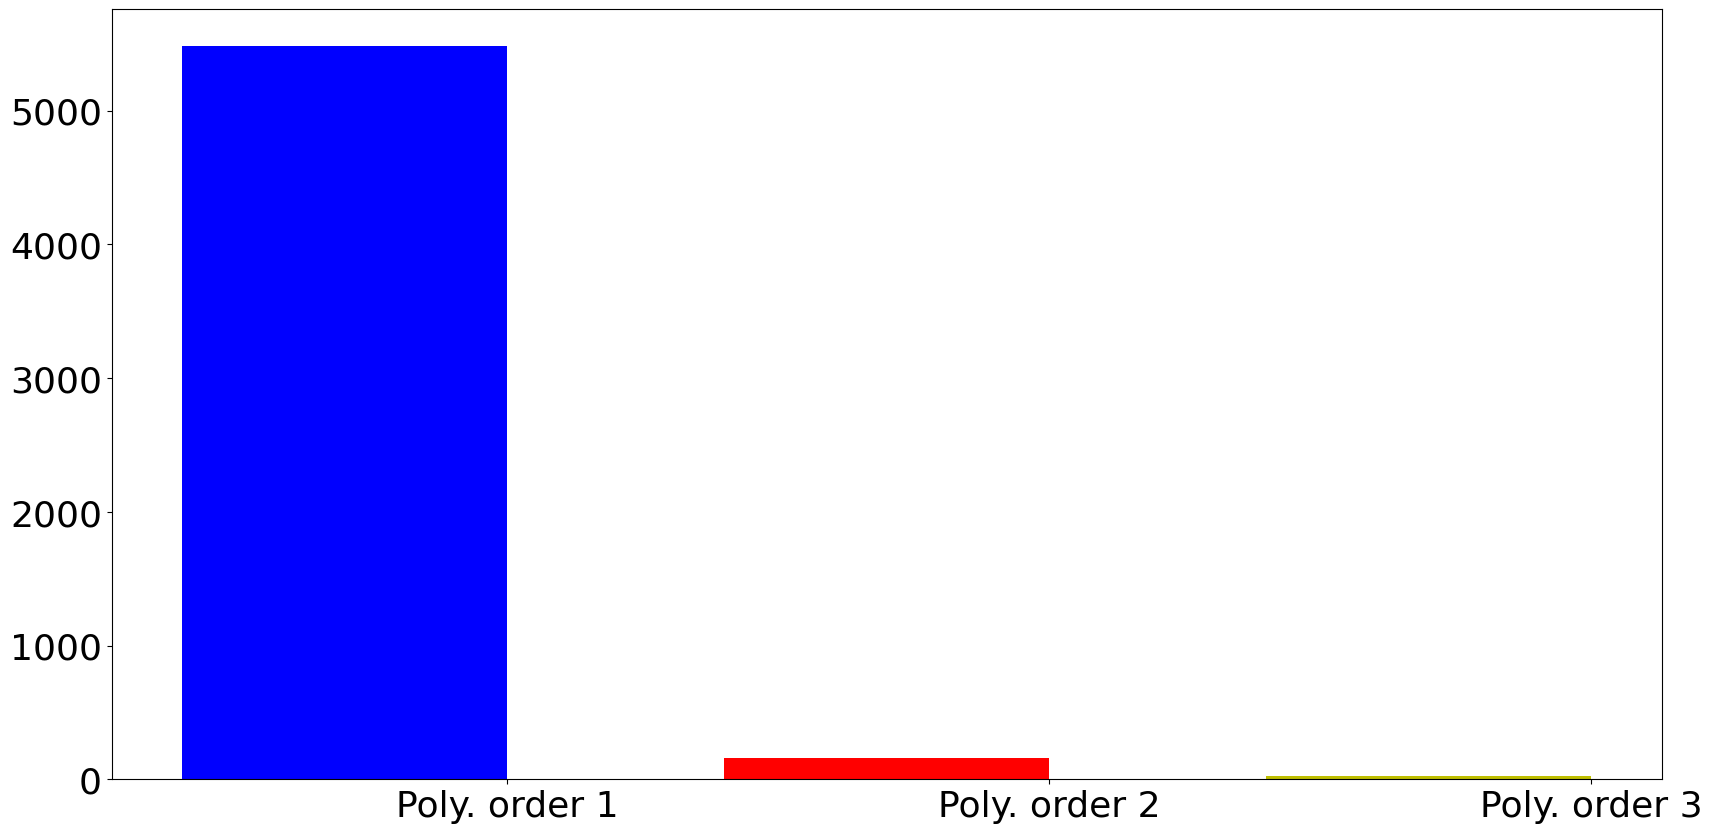

In [ ]:
# Visualize fit error for each year

x = df_hist.year
width = 0.2   #size of the bar

fig = plt.figure(figsize=(20,10))
ax = fig.add_subplot(111)

p1 = ax.bar( x, errors_hist[0], width, color = 'b', label = 'Abs. error order 1 fit')
p2 = ax.bar( x + width, errors_hist[1], width, color = 'r', label = 'Abs. error order 2 fit')
p3 = ax.bar( x + 2*width, errors_hist[2], width, color = 'y', label = 'Abs. error order 3 fit')

# "Prettyfy" the bar graph
ax.set_xticks(x+2*width)
ax.set_xticklabels(x)
plt.legend(loc = 'upper left', fontsize =16)
plt.show()

#Visualise MSE for each model
fig = plt.figure(figsize=(20,10))
ax = fig.add_subplot(111)

x = np.array([0,1,2])
width = .6   #size of the bar

p1 = ax.bar( x[0], mse_hist[0], width, color = 'b', label = 'pred. error order 1 fit')
p2 = ax.bar( x[1], mse_hist[1], width, color = 'r', label = 'pred. error order 2 fit')
p3 = ax.bar( x[2], mse_hist[2], width, color = 'y', label = 'pred. error order 3 fit')

ax.set_xticks(x+width/2)
ax.set_xticklabels(['Poly. order 1', 'Poly. order 2', 'Poly. order 3'], rotation=0)
plt.show()

Interpret the result of the fit error for each year


<font color = skyblue>
The provided data represents the absolute errors for three polynomial fits (orders 1, 2, and 3) applied to a variable named "traffic." The errors are calculated for 10 data points. The mean squared errors (MSE) for the fits are 5483.84, 156.257, and 25.172, respectively. A lower MSE indicates a better fit, suggesting that the cubic fit (order 3) is the best among the three. By analyzing the absolute errors and MSE values, we can gain insights into the performance of each fit at different data points and select the most suitable model for our specific application.

 </font>

In [ ]:
# Polynomial function order
order = 3

x = df_hist.year.values      # regressor
y = df_hist.traffic.values   # regressand

# Fit the model, return the polynomial parameter values in a numpy array such that
# y = p[0]*x**order + p[1]*x*(order-1) ...

p_array = np.polyfit(x,y,order)

print(type(p_array), p_array)

# poly1d is a convenience class, used to encapsulate “natural” operations on polynomials
# so that said operations may take on their customary form in code

# wrap the p_array in a poly1 object
p = np.poly1d(p_array)

print(type(p), p)

# use the poly1d object to evaluate the value of the polynomial in a specific point
print('The value of the polynomial for x = 2020 is : {} '.format(p(2020)))

# compute the absolute error for each value of x and the MSE error for the estimated polynomial model
e = np.abs(y-p(x))
mse = np.sum(e**2)/len(x)

print('The estimated polynomial parameters are: {}'.format(p))
print('The errors for each value of x, given the estimated polynomial parameters are: \n {}'.format(e))
print('The MSE is :{}'.format(mse))

<class 'numpy.ndarray'> [ 4.83129404e-01 -2.90500578e+03  5.82252085e+06 -3.89005387e+09]
<class 'numpy.poly1d'>         3        2
0.4831 x - 2905 x + 5.823e+06 x - 3.89e+09
The value of the polynomial for x = 2020 is : 2328.5784521102905 
The estimated polynomial parameters are:         3        2
0.4831 x - 2905 x + 5.823e+06 x - 3.89e+09
The errors for each value of x, given the estimated polynomial parameters are: 
 [1.30743027 0.39125264 2.02722693 6.32983208 5.28394403 0.93069802
 9.41692212 7.34010081 6.27729748 4.48133933 0.16291521]
The MSE is :25.17218620372407


#### Using sklearn to perform polynomial regression

Import the necessary libraries

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

Training the Polynomial Regression model  using degree 3

In [ ]:
poly_reg = PolynomialFeatures(degree=3)
X_poly = poly_reg.fit_transform(x.reshape(-1, 1))


In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly,y)


LinearRegression()

Predict the result using polynomial regression model

In [ ]:
y_pred = lin_reg.predict(X_poly)


In [ ]:
df = pd.DataFrame({'Real Values': y, 'Predicted Values':y_pred})

In [ ]:
df

,Real Values,Predicted Values
0,100.000000,101.241620
1,126.933755,127.295559
2,160.303757,158.270686
3,203.390603,197.068289
4,241.292566,246.589652
5,308.791823,309.736069
6,379.980659,389.408823
7,495.840568,488.509205
8,616.207252,609.938500
9,752.103483,756.598000


Visualize the Polynomial Regression results

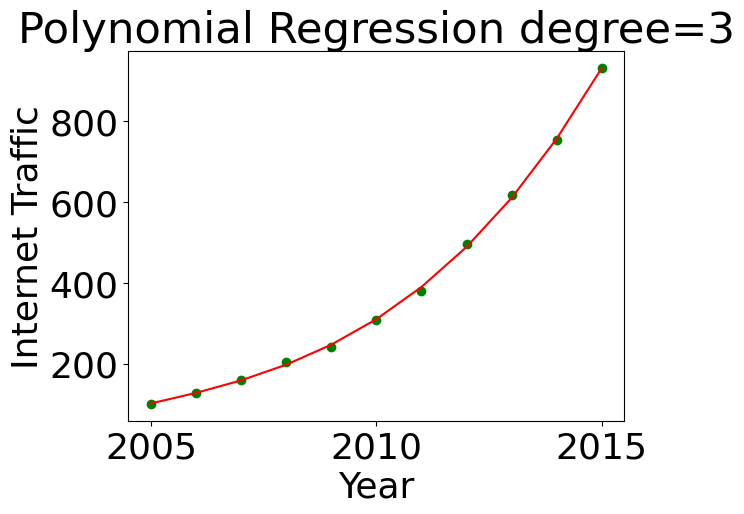

In [ ]:
plt.scatter(x, y, color='green')
plt.plot(x, y_pred, color = 'red')

plt.title("Polynomial Regression degree=3")
plt.xlabel('Year')
plt.ylabel('Internet Traffic')


plt.show();

Supplementary Activity:
* Choose your own dataset
* Import the dataset
* Perform polynomial regression using sklearn and polyfit
* Measure the performance for each polynomial degree.
* Plot the performance of the model for each polynomial degree.


## About Dataset

The data set was obtained from measurements made in a system for supervising the power generated by a photovoltaic panel, the supervision system consists of an electronic system based on an ATmega328P microcontroller with sensors that measure the following variables: ultraviolet irradiance measured in milliWatt per square centimeter (mW/cm2), temperature measured in degrees Celsius (C°), relative humidity measured in percent (%), illuminance measured on a custom scale from 0 to 1023, not using the international system of units for illuminance (lux); electrical potential measured in volts (V), and electrical current measured in amperes (A). The microcontroller has the capacity and the modules that allow it to receive the data of the variables obtained by the sensors and send them to a server located on the Internet, the server has a database that stores the variables, the supervision system sends the data to the server every minute, so in one day 1440 records are obtained, the data group is made up of 5801 records or rows, which corresponds to approximately four days, from 15 from July to July 19, 2023, in the district of Puno, Peru with coordinates: 15° 50′ 46″ S 70° 01′ 22″ W and at an altitude of 3840 m.s.n.m. The data is obtained from a monocrystalline photovoltaic panel with a power of 100 Watts, which has a voltage at maximum power of 18.3 V, a current at maximum power of 5.47 A, an open circuit voltage of 22.42 V and a current at short circuit of 5.76 A, a temperature range for its operation from -40 C° to +85 C°. The supervision system is provided with sensors that can measure the electric potential and the electric current that is transferred from the photovoltaic panel to a power resistor that has a value of 7.6 ohms, knowing that the panel Photovoltaic provides direct current, you can find the power that is generated by multiplying electric potential and electric current. Sensors are also used to measure ultraviolet irradiance, temperature, humidity, and illuminance; all the sensors send the data to the supervision system and this is in charge of sending the data to the server. According to Ohm's law, if we have a power resistance of 7.6 ohms and an open circuit voltage of the photovoltaic panel of 22.42 V, which is considered as the maximum operating voltage, there is an electric current in the resistance of 2.95 A, which would generate a maximum power of 66,139 W. These data are important because the theory has to coincide with the data obtained in a practical way and thus validate the data set.

In [ ]:
#import the data
df = pd.read_csv('/content/Photovoltaic_Power.txt',header = None)
df.to_csv('path_to_csv_file.csv', index=False)
df.columns = ["ID", "Temperature", "Humidity", "UV","Voltage", "Current", "Illuminance", "ClientIP","SensorID", "DateTime"]

In [ ]:
df

,ID,Temperature,Humidity,UV,Voltage,Current,Illuminance,ClientIP,SensorID,DateTime
0,359002,37.1,16.8,5.43,22.02,3.10,1011.75,179.7.224.186,PUN-JG167-S1,2023-07-15 13:15:18
1,359003,36.6,16.2,5.43,22.11,3.09,1012.30,179.7.224.186,PUN-JG167-S1,2023-07-15 13:16:18
2,359004,36.1,16.6,5.43,22.09,3.10,1011.85,179.7.224.186,PUN-JG167-S1,2023-07-15 13:17:18
3,359005,37.1,16.7,5.28,22.09,3.07,1011.75,179.7.224.186,PUN-JG167-S1,2023-07-15 13:18:18
4,359006,37.4,15.4,5.33,22.08,3.09,1011.80,179.7.224.186,PUN-JG167-S1,2023-07-15 13:19:19
...,...,...,...,...,...,...,...,...,...,...
5796,364798,28.2,18.3,1.22,12.11,1.83,1003.90,179.7.224.186,PUN-JG167-S1,2023-07-19 15:46:34
5797,364799,27.9,18.5,1.08,12.02,1.81,1004.25,179.7.224.186,PUN-JG167-S1,2023-07-19 15:47:35
5798,364800,28.2,18.5,1.12,11.89,1.81,1004.25,179.7.224.186,PUN-JG167-S1,2023-07-19 15:48:35
5799,364801,28.0,18.6,1.12,11.57,1.76,1004.30,179.7.224.186,PUN-JG167-S1,2023-07-19 15:49:36


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5801 entries, 0 to 5800
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ID           5801 non-null   int64  
 1   Temperature  5801 non-null   float64
 2   Humidity     5801 non-null   float64
 3   UV           5801 non-null   float64
 4   Voltage      5801 non-null   float64
 5   Current      5801 non-null   float64
 6   Illuminance  5801 non-null   float64
 7   ClientIP     5801 non-null   object 
 8   SensorID     5801 non-null   object 
 9   DateTime     5801 non-null   object 
dtypes: float64(6), int64(1), object(3)
memory usage: 453.3+ KB


In [ ]:
#make a new dataframe called df_tcr include the following columns: Temperature,humidity,uv,voltage and current.
df_tcr = df[['Temperature', 'Humidity', 'UV', 'Voltage', 'Current']]
df_tcr.head(10)
df_tcr.sort_values(by=['Voltage'])

,Temperature,Humidity,UV,Voltage,Current
2273,3.3,48.7,0.00,0.00,0.19
1944,9.2,40.5,0.05,0.00,0.17
1945,9.1,40.3,0.00,0.00,0.18
1946,9.0,40.2,0.00,0.00,0.19
1947,9.1,40.2,0.00,0.00,0.19
...,...,...,...,...,...
1406,32.6,16.8,6.50,22.33,3.15
1394,33.2,16.3,7.18,22.36,3.15
1397,31.5,18.0,6.94,22.39,3.16
1395,31.4,17.5,7.04,22.39,3.14


In [ ]:
#calculate the power
df_tcr['Power'] = df_tcr['Voltage'] * df_tcr['Current']
df_tcr.head(10)

<ipython-input-220-7e3d48baa9f1>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tcr['Power'] = df_tcr['Voltage'] * df_tcr['Current']


,Temperature,Humidity,UV,Voltage,Current,Power
0,37.1,16.8,5.43,22.02,3.10,68.2620
1,36.6,16.2,5.43,22.11,3.09,68.3199
2,36.1,16.6,5.43,22.09,3.10,68.4790
3,37.1,16.7,5.28,22.09,3.07,67.8163
4,37.4,15.4,5.33,22.08,3.09,68.2272
5,37.3,16.0,5.23,22.01,3.09,68.0109
6,36.9,16.2,5.08,22.10,3.08,68.0680
7,38.0,15.2,5.08,22.12,3.08,68.1296
8,38.1,15.3,5.08,22.11,3.08,68.0988
9,38.0,15.5,5.13,22.08,3.10,68.4480


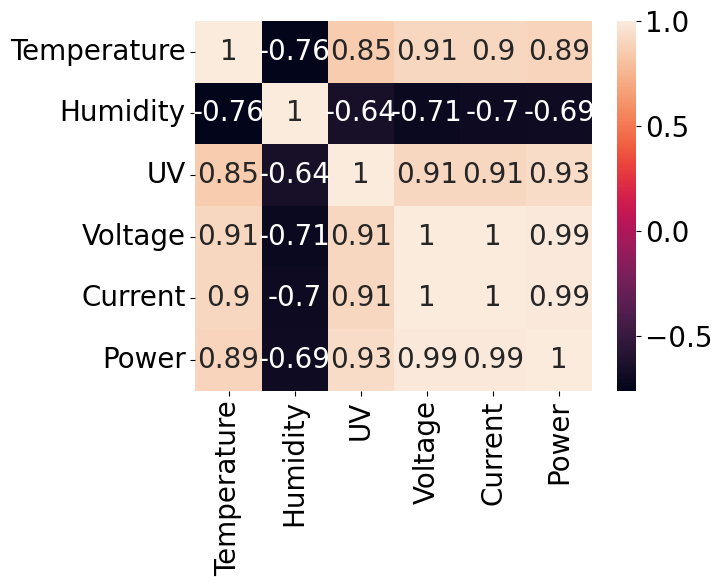

<Figure size 1500x1000 with 0 Axes>

In [ ]:
#plot the correlation matrix
corr_matrix = df_tcr.corr()
sns.heatmap(corr_matrix, annot=True)
plt.figure(figsize=(15, 10))
plt.show()
#adjust label font size
plt.rcParams.update({'font.size': 26})

In [ ]:
corr_matrix['UV']

,UV
Temperature,0.854601
Humidity,-0.644020
UV,1.000000
Voltage,0.909940
Current,0.908075
Power,0.926466


In [ ]:
#make a sample from the dataset
sample_df = df_tcr.sample(n=100)
sample_df = sample_df.sort_values(by=['UV'])
sample_df = sample_df.reset_index(drop=True)
sample_df.head(10)

,Temperature,Humidity,UV,Voltage,Current,Power
0,2.4,47.0,0.0,0.08,0.25,0.02
1,2.6,48.9,0.0,0.00,0.22,0.00
2,11.0,25.6,0.0,0.00,0.15,0.00
3,9.6,27.0,0.0,0.00,0.15,0.00
4,11.2,52.1,0.0,0.00,0.16,0.00
5,1.9,31.5,0.0,0.00,0.14,0.00
6,9.6,44.4,0.0,0.00,0.16,0.00
7,7.1,40.2,0.0,0.00,0.16,0.00
8,8.7,51.6,0.0,0.00,0.16,0.00
9,4.2,27.1,0.0,0.00,0.15,0.00


Building the 1st degree polynomial fit using numpy and polyfit

The slope of line is 10.715352733292654.
The y intercept is 2.624085699112354.
The best fit simple linear regression line is 10.715352733292654x + 2.624085699112354.


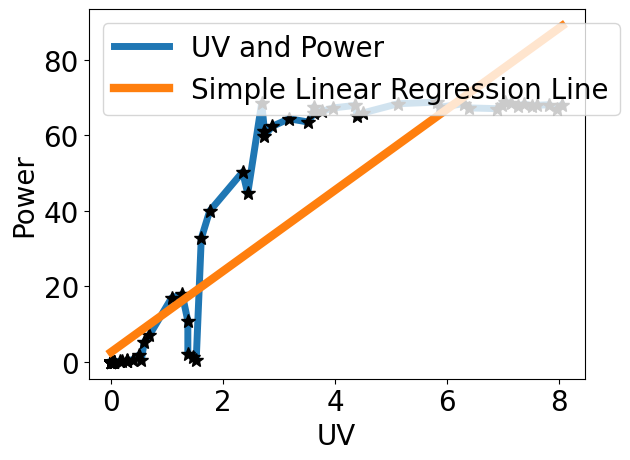

In [ ]:
order = 1

# XY Plot of Voltage and UV
x = sample_df.UV
y = sample_df.Power

m, b = np.polyfit(x,y,order)

plt.plot(x, y, label = 'UV and Power', linewidth = 5)
plt.plot(x, y,'*k', markersize = 10, label ='')
plt.plot(x, m*x + b, '-', label = 'Simple Linear Regression Line', linewidth = 6)

print ('The slope of line is {}.'.format(m))
print ('The y intercept is {}.'.format(b))
print ('The best fit simple linear regression line is {}x + {}.'.format(m,b))


#Increase sligthly the axis sizes to make the plot more clear
#plt.axis([x.iloc[0]-1, x.iloc[-1]+1, y.iloc[0]*-0.1, y.iloc[-1]*1.1])

# Add axis labels
plt.xlabel('UV')
plt.ylabel('Power')
plt.legend(loc = 'upper left')


# Increase default font size
plt.rcParams.update({'font.size': 20})
plt.show()

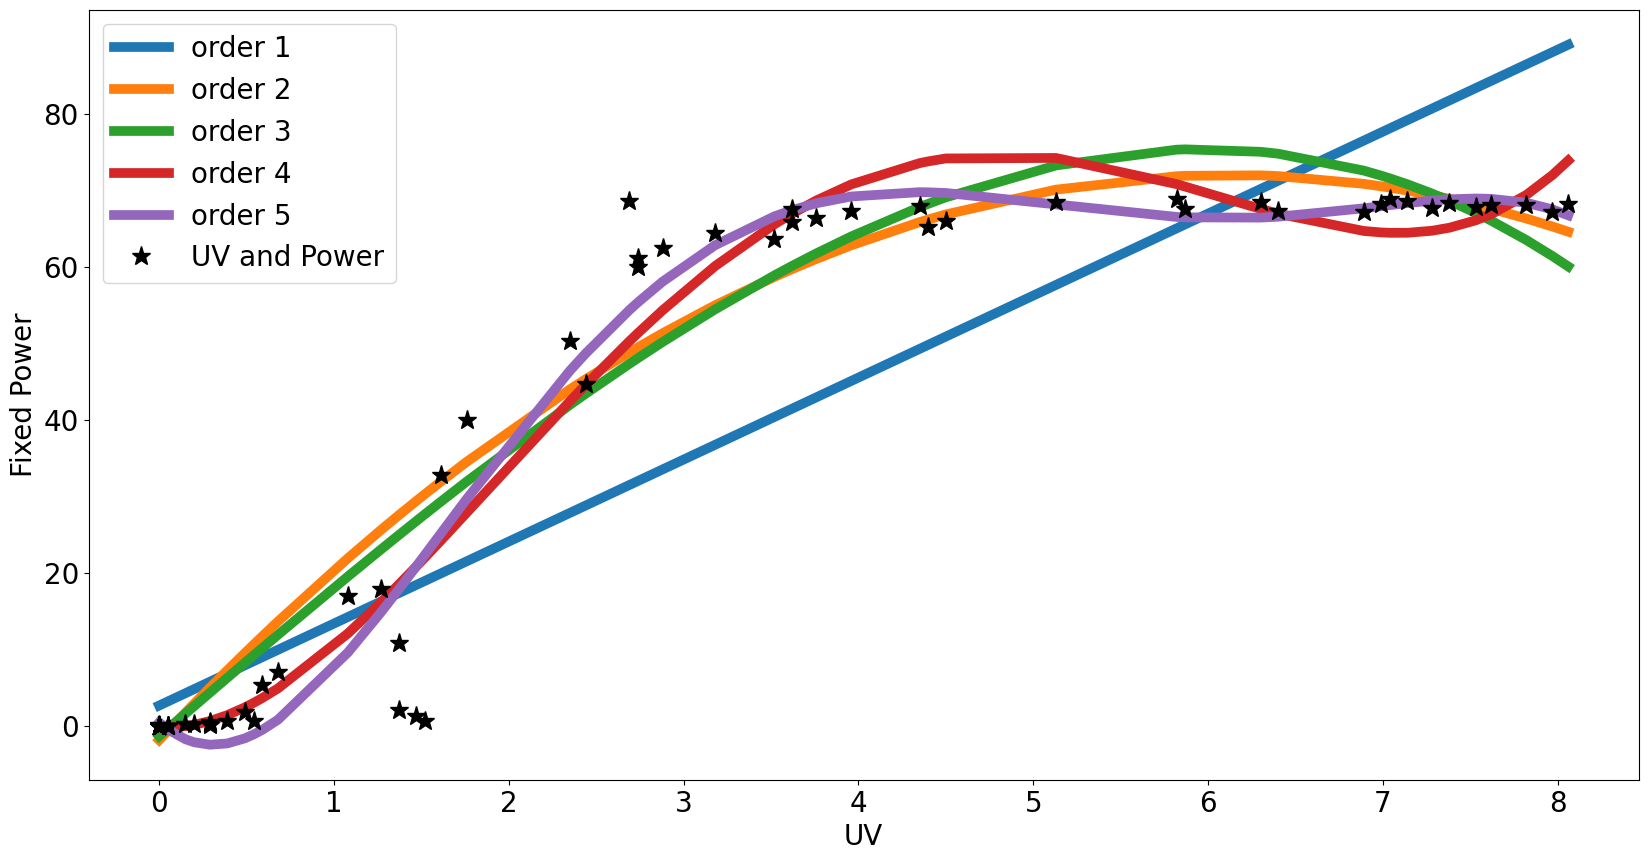

In [ ]:
models = []       # to store polynomial model parameters (list of poly1d objects)
errors_hist = []  # to store the absolute errors for each point (2005-2015) and for each model (list of numpy arrays )
mse_hist = []     # to store the MSE for each model (list of numpy floats)

#Try polynomial models with increasing order
for order in range(1,6):
    # Fit polynomial model
    p = (np.poly1d(np.polyfit(x, y, order)))
    models.append(p)

plt.figure(figsize = (20,10))

# Visualize polynomial models fit
for model in models[0:5]:
    plt.plot(x, model(x), label = 'order ' + str(len(model)), linewidth = 7)

plt.plot(x, y, '*k', markersize = 14, label = 'UV and Power', linewidth = 7)
plt.legend(loc = 'upper left')

# Add axis labels
plt.xlabel('UV')
plt.ylabel('Fixed Power')

plt.show()

In [ ]:
# Calculate and store the errors
models = []       # to store polynomial model parameters (list of poly1d objects)
errors_hist = []  # to store the absolute errors for each point (2005-2015) and for each model (list of numpy arrays )
mse_hist = []     # to store the MSE for each model (list of numpy floats)

#Try polynomial models with increasing order
for order in range(1,6):
    # Fit polynomial model
    p = (np.poly1d(np.polyfit(x, y, order)))
    models.append(p)

    e = np.abs(y-p(x))        # absolute error
    mse = np.sum(e**2)/len(df_hist) # mse

    errors_hist.append(e)   #Store the absolute errors
    mse_hist.append(mse) # Store the mse

In [ ]:
models

[poly1d([10.71535273,  2.6240857 ]),
 poly1d([-1.97262777, 24.14319976, -1.89037532]),
 poly1d([-0.16881246, -0.13677451, 19.68760966, -1.39538149]),
 poly1d([ 0.22261062, -3.54870059, 15.46977855, -1.52525591, -0.18068582]),
 poly1d([ -0.06520077,   1.48853441, -11.99953163,  37.65515127,
        -19.98625271,   0.4149764 ])]

In [ ]:
mse_hist

[1247.3209900147954,
 403.1263195703163,
 383.74339113341745,
 223.26300400253314,
 173.1888982744504]

In [ ]:
errors_hist

[0      2.604086
 1      2.624086
 2      2.624086
 3      2.624086
 4      2.624086
         ...    
 95    15.514892
 96    16.294074
 97    18.311544
 98    20.941447
 99    20.817829
 Name: Power, Length: 100, dtype: float64,
 0     1.910375
 1     1.890375
 2     1.890375
 3     1.890375
 4     1.890375
         ...   
 95    0.262349
 96    0.439641
 97    1.828075
 98    1.856164
 99    3.617186
 Name: Power, Length: 100, dtype: float64,
 0     1.415381
 1     1.395381
 2     1.395381
 3     1.395381
 4     1.395381
         ...   
 95    0.774513
 96    1.989724
 97    4.637071
 98    5.720436
 99    8.161935
 Name: Power, Length: 100, dtype: float64,
 0     0.200686
 1     0.180686
 2     0.180686
 3     0.180686
 4     0.180686
         ...   
 95    1.765250
 96    1.139862
 97    1.247141
 98    4.875165
 99    5.679902
 Name: Power, Length: 100, dtype: float64,
 0     0.394976
 1     0.414976
 2     0.414976
 3     0.414976
 4     0.414976
         ...   
 95    1.098251
 

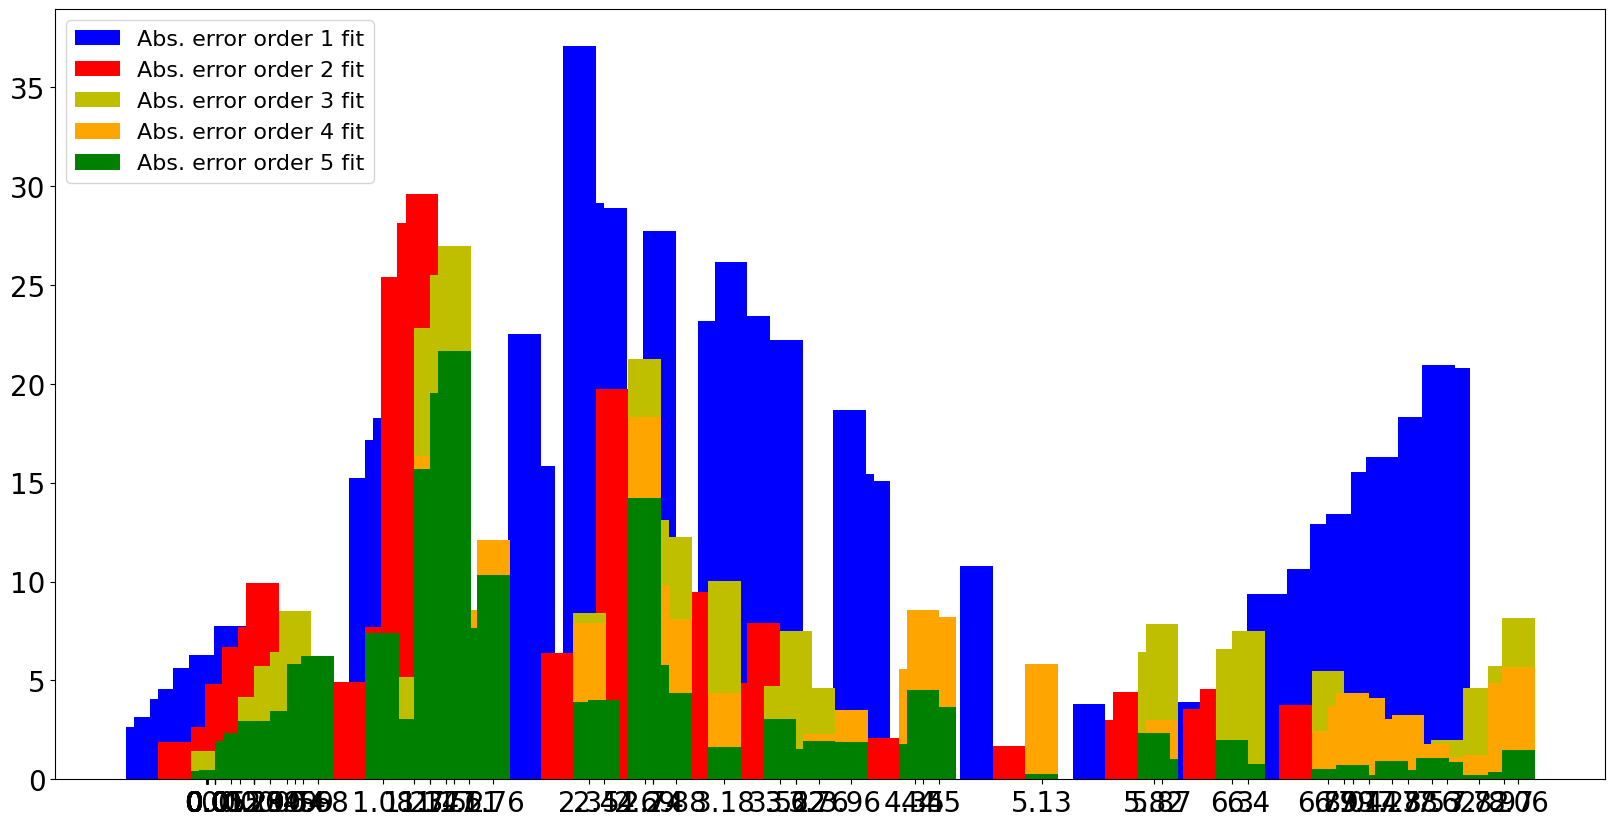

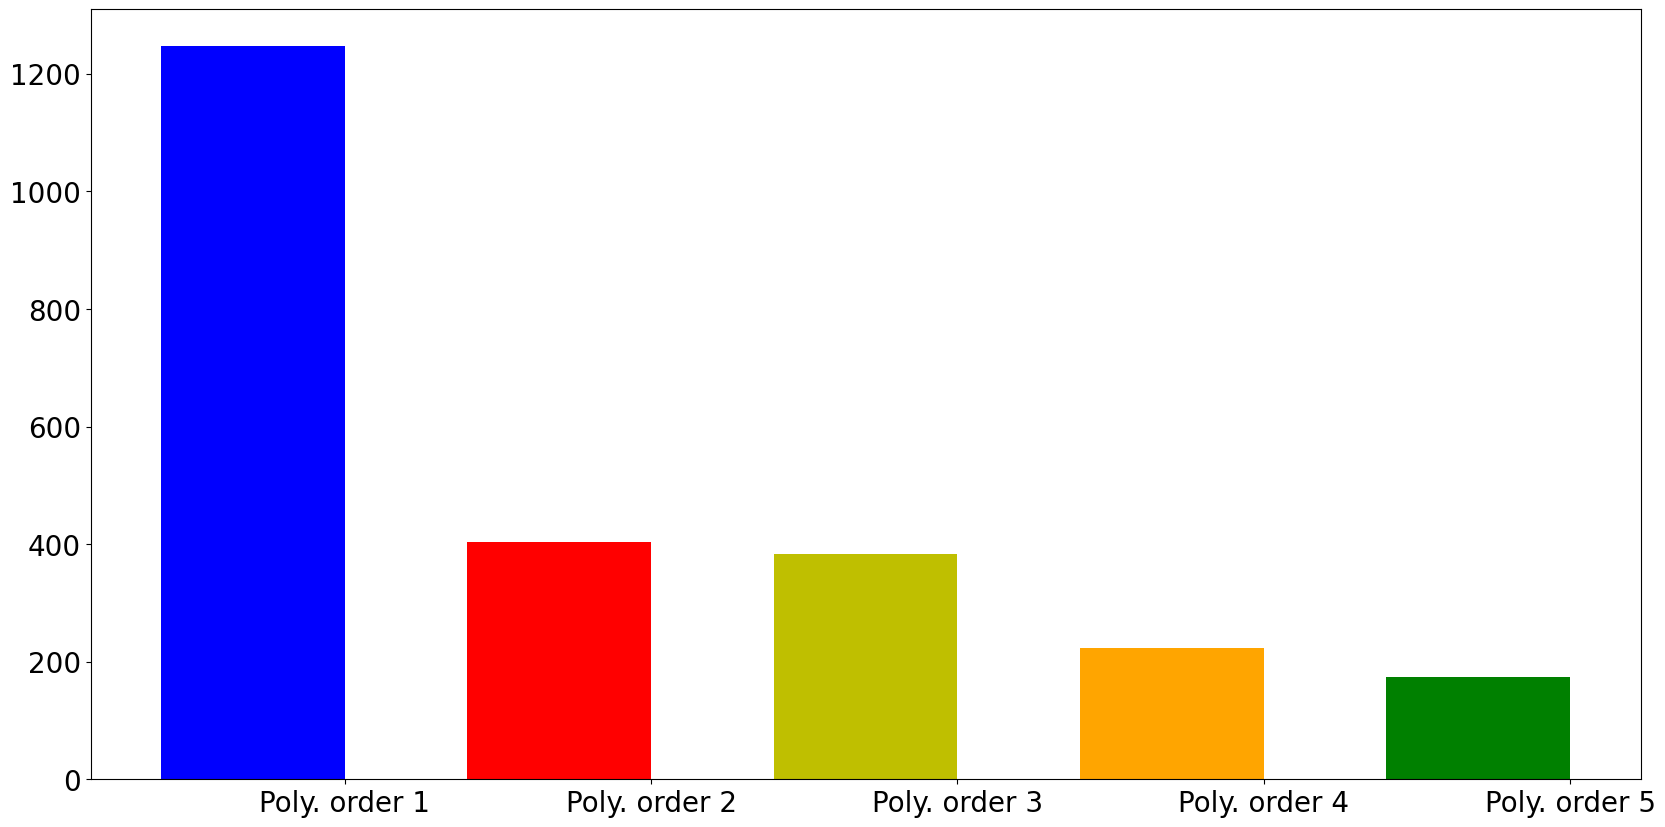

In [ ]:
# Visualize fit error for each year

x = sample_df.UV
width = 0.2   #size of the bar

fig = plt.figure(figsize=(20,10))
ax = fig.add_subplot(111)

p1 = ax.bar( x, errors_hist[0], width, color = 'b', label = 'Abs. error order 1 fit')
p2 = ax.bar( x + width, errors_hist[1], width, color = 'r', label = 'Abs. error order 2 fit')
p3 = ax.bar( x + 2*width, errors_hist[2], width, color = 'y', label = 'Abs. error order 3 fit')
p4 = ax.bar( x + 2*width, errors_hist[3], width, color = 'orange', label = 'Abs. error order 4 fit')
p5 = ax.bar( x + 2*width, errors_hist[4], width, color = 'g', label = 'Abs. error order 5 fit')


# "Prettyfy" the bar graph
ax.set_xticks(x+2*width)
ax.set_xticklabels(x)
plt.legend(loc = 'upper left', fontsize =16)
plt.show()

#Visualise MSE for each model
fig = plt.figure(figsize=(20,10))
ax = fig.add_subplot(111)

x = np.array([0,1,2,3,4])
width = .6   #size of the bar

p1 = ax.bar( x[0], mse_hist[0], width, color = 'b', label = 'pred. error order 1 fit')
p2 = ax.bar( x[1], mse_hist[1], width, color = 'r', label = 'pred. error order 2 fit')
p3 = ax.bar( x[2], mse_hist[2], width, color = 'y', label = 'pred. error order 3 fit')
p4 = ax.bar( x[3], mse_hist[3], width, color = 'orange', label = 'pred. error order 4 fit')
p5 = ax.bar( x[4], mse_hist[4], width, color = 'g', label = 'pred. error order 5 fit')

ax.set_xticks(x+width/2)
ax.set_xticklabels(['Poly. order 1', 'Poly. order 2', 'Poly. order 3','Poly. order 4','Poly. order 5'], rotation=0)
plt.show()

In [ ]:
# Polynomial function order
order = 5

x = sample_df.UV.values      # regressor
y = sample_df.Power.values   # regressand

# Fit the model, return the polynomial parameter values in a numpy array such that
# y = p[0]*x**order + p[1]*x*(order-1) ...

p_array = np.polyfit(x,y,order)

print(type(p_array), p_array)

# poly1d is a convenience class, used to encapsulate “natural” operations on polynomials
# so that said operations may take on their customary form in code

# wrap the p_array in a poly1 object
p = np.poly1d(p_array)

print(type(p), p)

# use the poly1d object to evaluate the value of the polynomial in a specific point
print('The value of the polynomial for x = 22 is : {} '.format(p(22)))

# compute the absolute error for each value of x and the MSE error for the estimated polynomial model
e = np.abs(y-p(x))
mse = np.sum(e**2)/len(x)

print('The estimated polynomial parameters are: {}'.format(p))
print('The errors for each value of x, given the estimated polynomial parameters are: \n {}'.format(e))
print('The MSE is :{}'.format(mse))

<class 'numpy.ndarray'> [ -0.06520077   1.48853441 -11.99953163  37.65515127 -19.98625271
   0.4149764 ]
<class 'numpy.poly1d'>          5         4      3         2
-0.0652 x + 1.489 x - 12 x + 37.66 x - 19.99 x + 0.415
The value of the polynomial for x = 22 is : -97307.88002590784 
The estimated polynomial parameters are:          5         4      3         2
-0.0652 x + 1.489 x - 12 x + 37.66 x - 19.99 x + 0.415
The errors for each value of x, given the estimated polynomial parameters are: 
 [ 0.3949764   0.4149764   0.4149764   0.4149764   0.4149764   0.4149764
  0.4149764   0.4149764   0.4149764   0.4149764   0.4149764   0.4149764
  0.4149764   0.4149764   0.4149764   0.4149764   0.4149764   0.4149764
  0.4149764   0.4149764   0.4149764   0.4149764   0.4149764   0.4149764
  0.4149764   0.4149764   0.4132764   0.4149764   0.4149764   0.4149764
  0.4149764   0.4149764   0.4149764   0.4149764   0.4149764   0.4149764
  0.4149764   0.4149764   0.4149764   0.4073764   0.4149764   0.4149

In [ ]:
#using Sklearn
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression


In [ ]:
poly_reg = PolynomialFeatures(degree=5)
X_poly = poly_reg.fit_transform(x.reshape(-1, 1))

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly,y)


LinearRegression()

In [ ]:
lin_reg.coef_

array([  0.        , -19.98625271,  37.65515127, -11.99953163,
         1.48853441,  -0.06520077])

In [ ]:
lin_reg.intercept_

0.41497639575518264

In [ ]:
y_pred = lin_reg.predict(X_poly)
y_pred

array([ 0.4149764 ,  0.4149764 ,  0.4149764 ,  0.4149764 ,  0.4149764 ,
        0.4149764 ,  0.4149764 ,  0.4149764 ,  0.4149764 ,  0.4149764 ,
        0.4149764 ,  0.4149764 ,  0.4149764 ,  0.4149764 ,  0.4149764 ,
        0.4149764 ,  0.4149764 ,  0.4149764 ,  0.4149764 ,  0.4149764 ,
        0.4149764 ,  0.4149764 ,  0.4149764 ,  0.4149764 ,  0.4149764 ,
        0.4149764 ,  0.4149764 ,  0.4149764 ,  0.4149764 ,  0.4149764 ,
        0.4149764 ,  0.4149764 ,  0.4149764 ,  0.4149764 ,  0.4149764 ,
        0.4149764 ,  0.4149764 ,  0.4149764 ,  0.4149764 ,  0.4149764 ,
        0.4149764 ,  0.4149764 ,  0.4149764 ,  0.4149764 ,  0.4149764 ,
        0.4149764 , -0.49168902, -0.49168902, -0.49168902, -0.49168902,
       -1.77547041, -2.16970356, -2.49650086, -2.49650086, -2.49650086,
       -2.49650086, -2.33026577, -1.66504922, -1.16327508, -0.55789662,
        0.77181915,  9.56417123, 14.84372212, 17.78280175, 17.78280175,
       20.79056007, 22.31098384, 25.06173293, 29.64261161, 46.39

In [ ]:
df_pred = pd.DataFrame({'Real Values': y, 'Predicted Values':y_pred})

In [ ]:
df_pred

,Real Values,Predicted Values
0,0.0200,0.414976
1,0.0000,0.414976
2,0.0000,0.414976
3,0.0000,0.414976
4,0.0000,0.414976
...,...,...
95,67.7958,68.894051
96,67.9810,68.848523
97,68.1066,68.337043
98,67.0840,67.467509


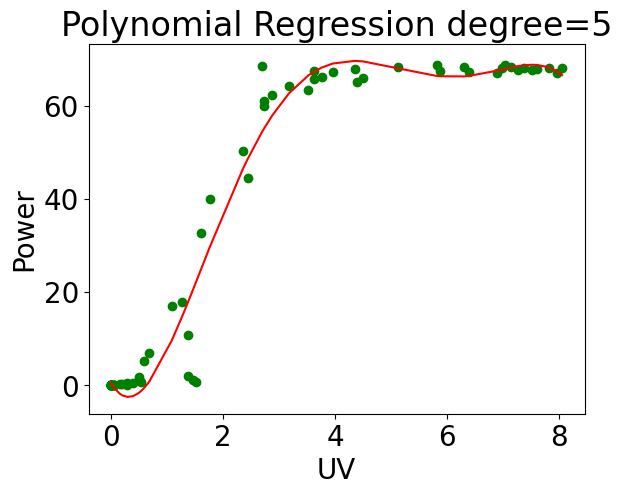

In [ ]:
plt.scatter(x, y, color='green')
plt.plot(x, y_pred, color = 'red')

plt.title("Polynomial Regression degree=5")
plt.xlabel('UV')
plt.ylabel('Power')


plt.show();

Conclusion:

<font color=skyblue>In this activity,we learn that Polynomial regression, implemented using polyfit and sklearn in Python, provides a powerful approach for modeling non-linear relationships between variables. In the context of photovoltaic (PV) power generation, polynomial regression can be effectively used to identify the non-linear relationship between ultraviolet (UV) radiation and power output. By understanding key metrics like MSE, error, and absolute error, we can assess model performance and make informed decisions. Feature engineering, including the creation of polynomial terms and interaction terms, plays a crucial role in capturing complex relationships and improving model accuracy. It's essential to be aware of the potential for overfitting, especially when using high-degree polynomials, and consider regularization techniques to mitigate this issue.  </font>

<font color =skyblue></font>